# Time-to-Event Regression — Last 7 Days  |  embed_dim=32

Predicts **days until hospital admission** (time to event) from home ventilator data.

- **Model**: Time-aware Transformer with Time2Vec (embed_dim=32, nhead=4, hidden=128)
- **Loss**: MSE (optimised) + MAE (reported)
- **Target**: log1p MinMax-scaled time to event (0–6 days)
- **Data**: label-1 patients only (hospitalised), last 7 days of monitoring
- **Save**: `Best_Model/regression_last7days/32dim/best_model.pth`


---
## Step 1 — Install & Import

In [1]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas pyarrow tqdm


In [2]:
import os, gc, math, contextlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import amp
from torch.cuda.amp import GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
GPU: Tesla T4


---
## Step 2 — Mount Drive & Load Label-1 Data

Loads pre-filtered label-1-only parquet directly — no re-filtering needed.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE         = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data"
LABEL1_DIR   = os.path.join(BASE, 'last7days_rawdata_label1only_parquet')
SAVE_DIR     = os.path.join(BASE, 'Best_Model', 'regression_last7days')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Label-1 data : {LABEL1_DIR}')
print(f'Save dir     : {SAVE_DIR}')

print('\nLoading label-1 only parquet...')
df_train = pd.read_parquet(os.path.join(LABEL1_DIR, 'train.parquet'))
df_val   = pd.read_parquet(os.path.join(LABEL1_DIR, 'val.parquet'))
df_test  = pd.read_parquet(os.path.join(LABEL1_DIR, 'test.parquet'))

print(f'Train: {len(df_train):,} rows  {df_train["patient_id"].nunique()} patients')
print(f'Val  : {len(df_val):,} rows  {df_val["patient_id"].nunique()} patients')
print(f'Test : {len(df_test):,} rows  {df_test["patient_id"].nunique()} patients')
df_train.head(3)


Mounted at /content/drive
Label-1 data : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/last7days_rawdata_label1only_parquet
Save dir     : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days

Loading label-1 only parquet...
Train: 32,455,977 rows  19 patients
Val  : 8,778,214 rows  5 patients
Test : 5,877,474 rows  5 patients


,timestamp,test_type,test_value,patient_id,label,start_date,end_date,machine_year_full,delta_time_seconds,time_from_start_seconds,patient_span_days,hour_of_day,hour_of_day_scaled,countdown_days_target,countdown_days_log_target,countdown_days_target_scaled,countdown_days_log_target_scaled,test_value_scaled,time_from_start_scaled,collection
0,2021-10-04 10:37:17.200,pressure,0.0,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,6.977046,10,0.416667,6,2.807355,1.0,1.0,0.0,0.000000e+00,train
1,2021-10-04 10:37:17.200,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,6.977046,10,0.416667,6,2.807355,1.0,1.0,0.0,0.000000e+00,train
2,2021-10-04 10:37:17.400,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.2,0.2,6.977046,10,0.416667,6,2.807355,1.0,1.0,0.0,3.306884e-07,train


---
## Step 3 — Scalers

All scalers fit on **train only** to prevent data leakage.
Target column renamed to `time_to_event_log_scaled` throughout.

In [4]:
# ── (A) Log-scaled time-to-event target ──────────────────────────────────────
# 'countdown_days_target' = days until hospital admission (time to event)
# We rename it conceptually as 'time_to_event_days' throughout
TTE_COL        = 'countdown_days_target'          # raw days column in parquet
LOG_SCALED_COL = 'time_to_event_log_scaled'       # new professional name

train_log = np.log1p(df_train[TTE_COL].astype(float).values).reshape(-1,1)
log_target_scaler = MinMaxScaler()
log_target_scaler.fit(train_log)

df_train[LOG_SCALED_COL] = log_target_scaler.transform(train_log)
df_val[LOG_SCALED_COL]   = log_target_scaler.transform(
    np.log1p(df_val[TTE_COL].astype(float).values).reshape(-1,1))
df_test[LOG_SCALED_COL]  = log_target_scaler.transform(
    np.log1p(df_test[TTE_COL].astype(float).values).reshape(-1,1))

mn = float(log_target_scaler.data_min_[0])
mx = float(log_target_scaler.data_max_[0])
print(f'time_to_event scaler: log_min={mn:.4f}  log_max={mx:.4f}')
print(f'  (raw range: {np.expm1(mn):.1f}–{np.expm1(mx):.1f} days)')

# ── (B) test_value_scaled per sensor type ────────────────────────────────────
TYPES = ['pressure', 'flow']
value_scalers = {}
for t in TYPES:
    mask_tr = df_train['test_type'] == t
    if mask_tr.sum() == 0: continue
    sc = MinMaxScaler()
    sc.fit(df_train.loc[mask_tr, 'test_value'].values.reshape(-1,1))
    value_scalers[t] = sc
    for df in [df_train, df_val, df_test]:
        mask = df['test_type'] == t
        if mask.sum() > 0:
            df.loc[mask, 'test_value_scaled'] = sc.transform(
                df.loc[mask, 'test_value'].values.reshape(-1,1)).flatten()
    print(f'  {t}: min={sc.data_min_[0]:.3f}  max={sc.data_max_[0]:.3f}')

# ── (C) time_from_start_scaled ────────────────────────────────────────────────
for df in [df_train, df_val, df_test]:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    if 'time_from_start_seconds' not in df.columns:
        min_ts = df.groupby('patient_id')['timestamp'].transform('min')
        df['time_from_start_seconds'] = (df['timestamp'] - min_ts).dt.total_seconds()

tfs_scaler = MinMaxScaler()
tfs_scaler.fit(df_train[['time_from_start_seconds']])
for df in [df_train, df_val, df_test]:
    df['time_from_start_scaled'] = tfs_scaler.transform(df[['time_from_start_seconds']])
print(f'time_from_start: {tfs_scaler.data_min_[0]:.0f}–{tfs_scaler.data_max_[0]:.0f} seconds')

# ── (D) hour_of_day_scaled ────────────────────────────────────────────────────
if 'hour_of_day' not in df_train.columns:
    for df in [df_train, df_val, df_test]:
        df['hour_of_day'] = df['timestamp'].dt.hour
hour_scaler = MinMaxScaler()
hour_scaler.fit(df_train[['hour_of_day']])
for df in [df_train, df_val, df_test]:
    df['hour_of_day_scaled'] = hour_scaler.transform(df[['hour_of_day']])

print('\n✅ All scalers fitted')
df_train.head(3)


time_to_event scaler: log_min=0.0000  log_max=1.9459
  (raw range: 0.0–6.0 days)
  pressure: min=0.000  max=192.380
  flow: min=-38.400  max=200.000
time_from_start: 0–604799 seconds

✅ All scalers fitted


,timestamp,test_type,test_value,patient_id,label,start_date,end_date,machine_year_full,delta_time_seconds,time_from_start_seconds,...,hour_of_day,hour_of_day_scaled,countdown_days_target,countdown_days_log_target,countdown_days_target_scaled,countdown_days_log_target_scaled,test_value_scaled,time_from_start_scaled,collection,time_to_event_log_scaled
0,2021-10-04 10:37:17.200,pressure,0.0,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,...,10,0.434783,6,2.807355,1.0,1.0,0.0,0.000000e+00,train,1.0
1,2021-10-04 10:37:17.200,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.0,0.0,...,10,0.434783,6,2.807355,1.0,1.0,0.0,0.000000e+00,train,1.0
2,2021-10-04 10:37:17.400,flow,-38.4,58,1,2021-10-04 10:37:17.200,2021-10-11 10:04:14,B3320402093_2023_bad,0.2,0.2,...,10,0.434783,6,2.807355,1.0,1.0,0.0,3.306884e-07,train,1.0


---
## Step 4 — Dataset & DataLoader

In [5]:
from torch.utils.data import Dataset
import torch, numpy as np, pandas as pd

class PatientTimeToEventDataset(Dataset):
    """
    Groups by (patient_id, time_to_event day), splits into bin_size-row chunks.
    Target: time_to_event_log_scaled (log1p MinMax scaled days to hospital admission).
    """
    def __init__(self, df, le_test_type, bin_size=24000):
        self.df       = df
        self.le       = le_test_type
        self.bin_size = bin_size
        self.feat_cols = ['test_value_scaled','time_from_start_scaled','hour_of_day_scaled']
        self.target_col = 'time_to_event_log_scaled'

        missing = [c for c in self.feat_cols + [self.target_col]
                   if c not in df.columns]
        if missing: raise ValueError(f'Missing columns: {missing}')

        self.groups = []
        gb = df.groupby(['patient_id', 'countdown_days_target'], sort=False)
        for (_, _), sub in gb:
            idx = sub.index.to_numpy()
            ts  = pd.to_datetime(sub['timestamp'], errors='coerce')
            valid = ts.notna().to_numpy()
            if not valid.any(): continue
            idx = idx[valid]
            ts  = ts[valid]
            order = np.argsort(ts.values.astype('datetime64[ns]'))
            idx_sorted = idx[order]
            for start in range(0, len(idx_sorted), self.bin_size):
                self.groups.append(idx_sorted[start:start+self.bin_size])

    def __len__(self): return len(self.groups)

    def __getitem__(self, i):
        gidx = self.groups[i]
        cols = ['timestamp','test_type'] + self.feat_cols + ['patient_id','countdown_days_target', self.target_col]
        g    = self.df.loc[gidx, cols]
        ts   = pd.to_datetime(g['timestamp'], errors='coerce')
        valid = ts.notna()
        if not valid.any():
            return {'test_type': torch.zeros(1,dtype=torch.long),
                    'test_value_scaled': torch.zeros(1),
                    'time_from_start_scaled': torch.zeros(1),
                    'hour_of_day_scaled': torch.zeros(1),
                    'target': torch.tensor([0.0]),
                    'patient_id': -1}
        g  = g.loc[valid].iloc[np.argsort(ts[valid].values.astype('datetime64[ns]'))]
        return {
            'test_type':             torch.tensor(self.le.transform(g['test_type']), dtype=torch.long),
            'test_value_scaled':     torch.tensor(g['test_value_scaled'].to_numpy(np.float32)),
            'time_from_start_scaled':torch.tensor(g['time_from_start_scaled'].to_numpy(np.float32)),
            'hour_of_day_scaled':    torch.tensor(g['hour_of_day_scaled'].to_numpy(np.float32)),
            'target':                torch.tensor([np.float32(g[self.target_col].iloc[0])]),
            'patient_id':            int(g['patient_id'].iloc[0]),
        }


In [6]:
uniq_types   = np.union1d(df_train['test_type'].unique(), df_val['test_type'].unique())
le_test_type = LabelEncoder().fit(uniq_types)
NUM_REAL_TYPES = len(le_test_type.classes_)
PAD_TYPE_ID    = NUM_REAL_TYPES
VALUE_TYPE_NUM = NUM_REAL_TYPES + 1
print(f'Sensor types: {le_test_type.classes_}  PAD_ID={PAD_TYPE_ID}')

BIN_SIZE = 24000
print('Building datasets...')
train_ds = PatientTimeToEventDataset(df_train, le_test_type, BIN_SIZE)
val_ds   = PatientTimeToEventDataset(df_val,   le_test_type, BIN_SIZE)
test_ds  = PatientTimeToEventDataset(df_test,  le_test_type, BIN_SIZE)
print(f'Chunks — train:{len(train_ds)}  val:{len(val_ds)}  test:{len(test_ds)}')

# ── Pre-cache entire dataset into RAM ────────────────────────────────────────
# One-time cost (~27 min for BIN_SIZE=24000).
# After this all epochs read from RAM — no Drive I/O per epoch.
# Results are identical — only delivery speed changes.
print('\nPre-caching datasets into RAM (one-time cost ~27 min)...')
print('Do not interrupt — run once then all epochs read from RAM\n')
import time

def cache_dataset_fast(ds, name):
    t0 = time.time()
    cache = []
    n = len(ds)
    for i in range(n):
        cache.append(ds[i])
        if (i+1) % 100 == 0 or (i+1) == n:
            elapsed = time.time() - t0
            eta     = (elapsed / (i+1)) * (n - i - 1)
            print(f'  {name}: {i+1}/{n}  '
                  f'elapsed={elapsed/60:.1f}min  '
                  f'ETA={eta/60:.1f}min')
    print(f'  ✅ {name} done: {n} chunks in {(time.time()-t0)/60:.1f} min\n')
    return cache

train_cache = cache_dataset_fast(train_ds, 'train')
val_cache   = cache_dataset_fast(val_ds,   'val')
test_cache  = cache_dataset_fast(test_ds,  'test')

ram = __import__('psutil').virtual_memory()
print(f'✅ All datasets cached in RAM')
print(f'RAM used: {ram.used/1024**3:.1f} GB / {ram.total/1024**3:.1f} GB')


Sensor types: ['flow' 'pressure']  PAD_ID=2
Building datasets...
Chunks — train:1412  val:382  test:259

Pre-caching datasets into RAM (one-time cost ~27 min)...
Do not interrupt — run once then all epochs read from RAM

  train: 100/1412  elapsed=1.9min  ETA=24.4min
  train: 200/1412  elapsed=3.7min  ETA=22.4min
  train: 300/1412  elapsed=5.5min  ETA=20.5min
  train: 400/1412  elapsed=7.4min  ETA=18.6min
  train: 500/1412  elapsed=9.2min  ETA=16.7min
  train: 600/1412  elapsed=11.0min  ETA=14.9min
  train: 700/1412  elapsed=12.9min  ETA=13.1min
  train: 800/1412  elapsed=14.8min  ETA=11.3min
  train: 900/1412  elapsed=16.6min  ETA=9.5min
  train: 1000/1412  elapsed=18.5min  ETA=7.6min
  train: 1100/1412  elapsed=20.4min  ETA=5.8min
  train: 1200/1412  elapsed=22.2min  ETA=3.9min
  train: 1300/1412  elapsed=24.1min  ETA=2.1min
  train: 1400/1412  elapsed=26.0min  ETA=0.2min
  train: 1412/1412  elapsed=26.2min  ETA=0.0min
  ✅ train done: 1412 chunks in 26.2 min

  val: 100/382  elapsed=

In [7]:
def collate_fn(batch):
    tt  = [s['test_type']               for s in batch]
    tv  = [s['test_value_scaled']        for s in batch]
    tfs = [s['time_from_start_scaled']   for s in batch]
    hod = [s['hour_of_day_scaled']       for s in batch]
    y   = [s['target'].view(-1)          for s in batch]
    pids= [s['patient_id']               for s in batch]

    test_type       = pad_sequence(tt,  batch_first=True, padding_value=PAD_TYPE_ID).long()
    test_value      = pad_sequence(tv,  batch_first=True, padding_value=0.0).float()
    time_from_start = pad_sequence(tfs, batch_first=True, padding_value=0.0).float()
    hour_of_day     = pad_sequence(hod, batch_first=True, padding_value=0.0).float()
    lengths         = torch.tensor([len(t) for t in tt], dtype=torch.long)
    T               = test_type.size(1)
    attn_mask       = torch.arange(T).unsqueeze(0) < lengths.unsqueeze(1)
    padding_mask    = ~attn_mask
    target          = torch.stack(y, dim=0).squeeze(1).float()
    return (padding_mask, test_type, test_value, time_from_start,
            hour_of_day, target, pids, attn_mask)


# ── DataLoaders — reads from RAM cache, num_workers=0 (Colab multiprocessing broken)
BATCH_SIZE = 64
BASE_LR    = 1e-3 * (BATCH_SIZE / 20)   # linear scaling rule: lr scales with batch size
print(f'Batch size   : {BATCH_SIZE}')
print(f'Learning rate: {BASE_LR:.6f}  (scaled from lr=1e-3 at bs=20)')

train_loader = DataLoader(train_cache, BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_cache,   BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_cache,  BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
print(f'Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}')

# Sanity check
b = next(iter(train_loader))
names = ['padding_mask','test_type','test_value','time_from_start','hour_of_day','target','pids','attn_mask']
for n, t in zip(names, b):
    if hasattr(t,'shape'): print(f'  {n}: {tuple(t.shape)}  dtype={t.dtype}')
    else: print(f'  {n}: list[{len(t)}]')


Batch size   : 64
Learning rate: 0.003200  (scaled from lr=1e-3 at bs=20)
Batches — train:23  val:6  test:5
  padding_mask: (64, 24000)  dtype=torch.bool
  test_type: (64, 24000)  dtype=torch.int64
  test_value: (64, 24000)  dtype=torch.float32
  time_from_start: (64, 24000)  dtype=torch.float32
  hour_of_day: (64, 24000)  dtype=torch.float32
  target: (64,)  dtype=torch.float32
  pids: list[64]
  attn_mask: (64, 24000)  dtype=torch.bool


---
## Step 5 — Model: Time-to-Event Transformer

In [8]:
import torch, torch.nn as nn, math

class Time2Vec(nn.Module):
    """Learnable time encoding (Kazemi et al. 2019)."""
    def __init__(self, embed_dim):
        super().__init__()
        assert embed_dim >= 2
        self.linear   = nn.Linear(1, 1)
        self.periodic = nn.Linear(1, embed_dim - 1)
    def forward(self, x):
        if x.dim() == 2: x = x.unsqueeze(-1)
        return torch.cat([self.linear(x), torch.sin(self.periodic(x))], dim=-1)


class TimeToEventTransformer(nn.Module):
    """
    Time-aware Transformer for time-to-event regression.
    Inputs  : sensor type, sensor value, time_from_start (Time2Vec), hour_of_day (Time2Vec)
    Output  : scalar — log-scaled time to hospital admission
    """
    def __init__(self, value_type_num, embed_dim=32, nhead=4,
                 num_layers=2, hidden_dim=128, dropout=0.2, pool_size=4):
        super().__init__()
        assert embed_dim % nhead == 0
        self.pool_size = max(1, pool_size)

        self.type_emb   = nn.Embedding(value_type_num, embed_dim, padding_idx=value_type_num-1)
        self.value_fc   = nn.Linear(1, embed_dim)
        self.tfs_t2v    = Time2Vec(embed_dim)   # time from patient start
        self.hod_t2v    = Time2Vec(embed_dim)   # hour of day
        self.norm_in    = nn.LayerNorm(embed_dim)
        self.drop_in    = nn.Dropout(dropout)
        self.pos_scale  = math.sqrt(embed_dim)
        self.pos_emb    = None                  # grown lazily

        enc = nn.TransformerEncoderLayer(embed_dim, nhead, hidden_dim,
                                          dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(enc, num_layers)
        self.out_norm   = nn.LayerNorm(embed_dim)
        self.head       = nn.Sequential(
            nn.Linear(embed_dim, 16), nn.ReLU(),
            nn.Dropout(dropout),     nn.Linear(16, 1))

    def _temporal_pool(self, x, mask):
        P = self.pool_size
        if P == 1: return x, mask
        B, T, D = x.shape
        Tt = (T // P) * P
        if Tt == 0:
            v = (~mask).float().unsqueeze(-1)
            return (x*v).sum(1,keepdim=True)/v.sum(1).clamp(1e-6), (v.sum(1)==0)
        x, mask = x[:,:Tt,:], mask[:,:Tt]
        v = (~mask.view(B,Tt//P,P)).float().unsqueeze(-1)
        out = (x.view(B,Tt//P,P,D)*v).sum(2)/v.sum(2).clamp(1e-6)
        return out, (v.sum(2).squeeze(-1)==0)

    def _pos_enc(self, x):
        B, T, D = x.shape
        if self.pos_emb is None or self.pos_emb.size(0) < T:
            pe = torch.empty(T, D, device=x.device, dtype=x.dtype)
            nn.init.normal_(pe, std=0.02)
            self.pos_emb = nn.Parameter(pe)
        return x + self.pos_emb[:T].unsqueeze(0) * self.pos_scale

    def forward(self, padding_mask, value_types, values, tfs, hod):
        if values.dim()==2: values=values.unsqueeze(-1)
        x  = (self.type_emb(value_types)
              + self.value_fc(values)
              + self.tfs_t2v(tfs)
              + self.hod_t2v(hod))
        x  = self.drop_in(self.norm_in(x))
        x, pm = self._temporal_pool(x, padding_mask)
        x  = self._pos_enc(x)
        h  = self.encoder(x, src_key_padding_mask=pm)
        v  = (~pm).unsqueeze(-1).float()
        pooled = (h*v).sum(1) / v.sum(1).clamp(1e-6)
        return self.head(self.out_norm(pooled)).squeeze(-1)

print('TimeToEventTransformer defined.')


TimeToEventTransformer defined.


---
## Step 6 — Helpers (Inference & Metrics)

In [9]:
def autocast_ctx():
    if torch.cuda.is_available():
        try:    return torch.amp.autocast('cuda')
        except: return torch.cuda.amp.autocast()
    return contextlib.nullcontext()

def inv_log_scaled_to_days(x_scaled, scaler):
    """MinMax-scaled log1p(days) → actual days"""
    x = np.asarray(x_scaled, dtype=np.float32).reshape(-1,1)
    return np.expm1(scaler.inverse_transform(x).flatten().astype(np.float64)).clip(0, None)

def load_best_model(path, embed_dim, nhead, hidden_dim, num_layers=2):
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    m = TimeToEventTransformer(
        value_type_num=VALUE_TYPE_NUM, embed_dim=embed_dim,
        nhead=nhead, num_layers=num_layers, hidden_dim=hidden_dim).to(dev)
    m.load_state_dict(torch.load(path, map_location=dev), strict=False)
    m.eval()
    print(f'  ✅ Loaded {path}')
    return m, dev

@torch.no_grad()
def collect_predictions(loader, model, scaler, dev):
    rows = []
    for batch in loader:
        (pm, tt, tv, tfs, hod, targets, pids, _) = batch
        pm  = pm.to(dev); tt = tt.to(dev)
        tv  = torch.nan_to_num(tv.to(dev),  nan=0.0)
        tfs = torch.nan_to_num(tfs.to(dev), nan=0.0)
        hod = torch.nan_to_num(hod.to(dev), nan=0.0)
        with autocast_ctx():
            pred_s = model(pm, tt, tv, tfs, hod).detach().float().cpu().numpy()
        tgt_s  = np.asarray(targets, dtype=np.float32).flatten()
        yhat   = inv_log_scaled_to_days(pred_s,  scaler)
        ytrue  = inv_log_scaled_to_days(tgt_s,   scaler)
        day_idx = np.clip(np.rint(ytrue), 0, 6).astype(int)
        for pid, d, yt, yh in zip(np.asarray(pids), day_idx, ytrue, yhat):
            rows.append({'patient_id': pid, 'day': d,
                         'time_to_event_actual': yt,
                         'time_to_event_pred':   yh})
    return pd.DataFrame(rows)

def compute_metrics(df):
    daily = (df.groupby(['patient_id','day'], as_index=False)
               .agg(actual=('time_to_event_actual','mean'),
                    pred  =('time_to_event_pred',  'mean')))
    yt, yp = daily['actual'].values, daily['pred'].values
    mse  = float(mean_squared_error(yt, yp))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = (float(r2_score(yt, yp))
            if len(yt)>=2 and np.var(yt)>0 else float('nan'))
    return {'MSE':mse,'RMSE':rmse,'MAE':mae,'R2':r2,'daily':daily}

print('Helpers ready.')


Helpers ready.


---
## Step 7 — Train  (embed_dim=32)

Optimises **MSE** on log-scaled time-to-event. Early stopping patience=20.
Best model saved to `Best_Model/regression_last7days/32dim/best_model.pth`.

embed_dim=32  params=26,369
TimeToEventTransformer(
  (type_emb): Embedding(3, 32, padding_idx=2)
  (value_fc): Linear(in_features=1, out_features=32, bias=True)
  (tfs_t2v): Time2Vec(
    (linear): Linear(in_features=1, out_features=1, bias=True)
    (periodic): Linear(in_features=1, out_features=31, bias=True)
  )
  (hod_t2v): Time2Vec(
    (linear): Linear(in_features=1, out_features=1, bias=True)
    (periodic): Linear(in_features=1, out_features=31, bias=True)
  )
  (norm_in): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (drop_in): Dropout(p=0.2, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_

Train 1/200:   0%|          | 0/23 [00:00<?, ?it/s]

  Shapes: mask=(64, 24000) types=(64, 24000) target=(64,)
  Target range: [0.000, 1.000]  (expect 0..1)


  Ep 001  TrainMSE=0.28073  ValMSE=0.04403  TrainMAE=0.40614  ValMAE=0.15955  LR=0.003200  ✅ saved


  Ep 002  TrainMSE=0.06999  ValMSE=0.03216  TrainMAE=0.20512  ValMAE=0.13727  LR=0.003200  ✅ saved


...

  Ep 020  TrainMSE=0.04071  ValMSE=0.03682  TrainMAE=0.16196  ValMAE=0.16445  LR=0.001600  


  Ep 021  TrainMSE=0.04156  ValMSE=0.04657  TrainMAE=0.16751  ValMAE=0.16549  LR=0.001600  


  Ep 022  TrainMSE=0.03414  ValMSE=0.03572  TrainMAE=0.14583  ValMAE=0.14859  LR=0.001600  


  Ep 023  TrainMSE=0.03943  ValMSE=0.05092  TrainMAE=0.15905  ValMAE=0.17446  LR=0.001600  


  Early stopping at epoch 24


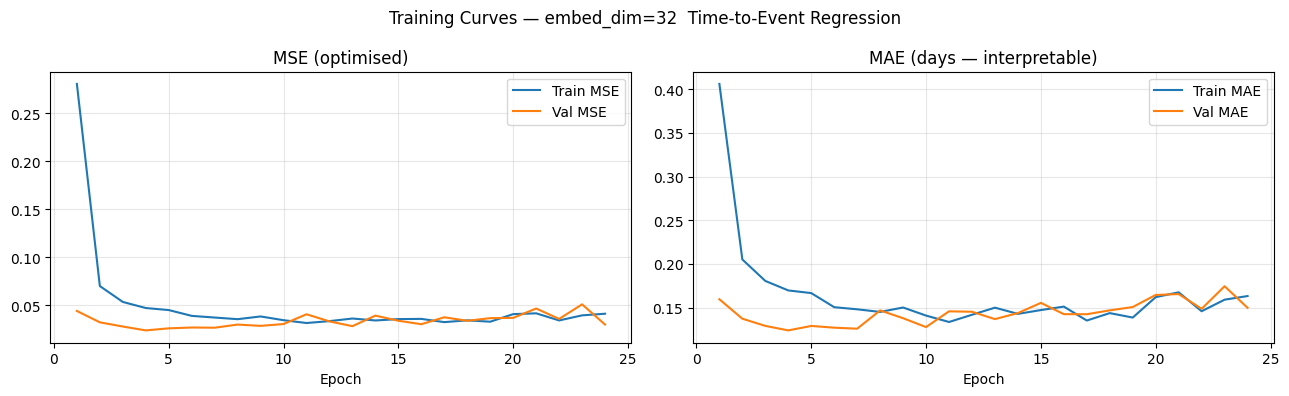


✅ Best Val MSE=0.02376
   Model saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days/32dim/best_model.pth


In [10]:
# ── Model ────────────────────────────────────────────────────────────────────
EMBED_DIM  = 32
NHEAD      = 4
HIDDEN_DIM = 128
NUM_LAYERS = 2

dim_save        = os.path.join(SAVE_DIR, f'{EMBED_DIM}dim')
os.makedirs(dim_save, exist_ok=True)
best_model_path = os.path.join(dim_save, 'best_model.pth')
loss_plot_path  = os.path.join(dim_save, 'loss_curve.png')

model = TimeToEventTransformer(
    value_type_num=VALUE_TYPE_NUM, embed_dim=EMBED_DIM,
    nhead=NHEAD, num_layers=NUM_LAYERS,
    hidden_dim=HIDDEN_DIM, dropout=0.2, pool_size=4,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'embed_dim={EMBED_DIM}  params={n_params:,}')
print(model)

criterion_mse = nn.MSELoss()   # optimised
criterion_mae = nn.L1Loss()    # reported
optimizer     = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=1e-5)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',factor=0.5,patience=10)
grad_scaler   = GradScaler(enabled=torch.cuda.is_available())

NUM_EPOCHS          = 200
EARLY_STOP_PATIENCE = 20
best_val_mse        = float('inf')
early_stop_cnt      = 0
history = {'train_mse':[],'val_mse':[],'train_mae':[],'val_mae':[]}
shape_logged = False

for epoch in range(1, NUM_EPOCHS+1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    tr_mse, tr_mae = [], []
    for batch in tqdm(train_loader, desc=f'Train {epoch}/{NUM_EPOCHS}', leave=False):
        try:
            pm, tt, tv, tfs, hod, tgt, pids, _ = batch
            pm  = pm.to(device); tt = tt.to(device)
            tv  = torch.nan_to_num(tv.to(device),  nan=0.0)
            tfs = torch.nan_to_num(tfs.to(device), nan=0.0)
            hod = torch.nan_to_num(hod.to(device), nan=0.0)
            tgt = torch.nan_to_num(torch.as_tensor(tgt,device=device,dtype=torch.float32),nan=0.0)
            if not shape_logged:
                print(f'  Shapes: mask={tuple(pm.shape)} types={tuple(tt.shape)} target={tuple(tgt.shape)}')
                print(f'  Target range: [{float(tgt.min()):.3f}, {float(tgt.max()):.3f}]  (expect 0..1)')
                shape_logged = True
            optimizer.zero_grad(set_to_none=True)
            with autocast_ctx():
                pred = model(pm, tt, tv, tfs, hod)
                loss_mse = criterion_mse(pred, tgt)
                loss_mae = criterion_mae(pred, tgt)
            if torch.isnan(loss_mse): continue
            grad_scaler.scale(loss_mse).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            grad_scaler.step(optimizer); grad_scaler.update()
            tr_mse.append(loss_mse.item()); tr_mae.append(loss_mae.item())
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache(); continue

    # ── Val ────────────────────────────────────────────────────────────────
    model.eval()
    va_mse, va_mae = [], []
    with torch.no_grad():
        for batch in val_loader:
            try:
                pm, tt, tv, tfs, hod, tgt, pids, _ = batch
                pm  = pm.to(device); tt = tt.to(device)
                tv  = torch.nan_to_num(tv.to(device),  nan=0.0)
                tfs = torch.nan_to_num(tfs.to(device), nan=0.0)
                hod = torch.nan_to_num(hod.to(device), nan=0.0)
                tgt = torch.nan_to_num(torch.as_tensor(tgt,device=device,dtype=torch.float32),nan=0.0)
                with autocast_ctx():
                    pred = model(pm, tt, tv, tfs, hod)
                    va_mse.append(criterion_mse(pred,tgt).item())
                    va_mae.append(criterion_mae(pred,tgt).item())
            except torch.cuda.OutOfMemoryError:
                torch.cuda.empty_cache(); continue

    t_mse = sum(tr_mse)/max(1,len(tr_mse)); t_mae = sum(tr_mae)/max(1,len(tr_mae))
    v_mse = sum(va_mse)/max(1,len(va_mse)); v_mae = sum(va_mae)/max(1,len(va_mae))
    history['train_mse'].append(t_mse); history['val_mse'].append(v_mse)
    history['train_mae'].append(t_mae); history['val_mae'].append(v_mae)
    scheduler.step(v_mse)
    lr_now = optimizer.param_groups[0]['lr']

    marker = ''
    if v_mse < best_val_mse:
        best_val_mse = v_mse
        state = model.module.state_dict() if isinstance(model,nn.DataParallel) else model.state_dict()
        torch.save(state, best_model_path)
        early_stop_cnt = 0; marker = '✅ saved'
    else:
        early_stop_cnt += 1
        if early_stop_cnt >= EARLY_STOP_PATIENCE:
            print(f'  Early stopping at epoch {epoch}'); break

    print(f'  Ep {epoch:03d}  TrainMSE={t_mse:.5f}  ValMSE={v_mse:.5f}  '
          f'TrainMAE={t_mae:.5f}  ValMAE={v_mae:.5f}  LR={lr_now:.6f}  {marker}')

# ── Loss curve ────────────────────────────────────────────────────────────────
ep = range(1, len(history['train_mse'])+1)
fig, axes = plt.subplots(1, 2, figsize=(13,4))
fig.suptitle(f'Training Curves — embed_dim={EMBED_DIM}  Time-to-Event Regression', fontsize=12)
axes[0].plot(ep, history['train_mse'], label='Train MSE')
axes[0].plot(ep, history['val_mse'],   label='Val MSE')
axes[0].set_title('MSE (optimised)'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history['train_mae'], label='Train MAE')
axes[1].plot(ep, history['val_mae'],   label='Val MAE')
axes[1].set_title('MAE (days — interpretable)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=150); plt.show()
print(f'\n✅ Best Val MSE={best_val_mse:.5f}')
print(f'   Model saved → {best_model_path}')
gc.collect(); torch.cuda.empty_cache()


---
## Step 8 — Evaluate & Paper Charts  (embed_dim=32)

Charts produced:
- Per-patient scatter: x=actual time to event, y=predicted time to event
- Combined scatter (test): predicted vs actual with R² in title
- Mean per-day line plot (train/val/test)
- Residual distribution histogram
- Per-patient per-day CSV table

  ✅ Loaded /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days/32dim/best_model.pth

  METRICS — embed_dim=32
   Split       MSE      RMSE       MAE        R²
  ---------------------------------------------
   train    1.1846    1.0884    0.9330    0.7109
     val    0.6674    0.8169    0.7047    0.8224
    test    0.9933    0.9966    0.8668    0.7641

  PER-PATIENT TABLE — TRAIN  (embed_dim=32)
  Columns: patient_id | day (0=event day, 6=6 days before) | actual_days | pred_days | error_days
 patient_id  day  actual_days  pred_days  error_days
         58    0          0.0      0.263       0.263
         58    1          1.0      0.638      -0.362
         58    2          2.0      1.038      -0.962
         58    3          3.0      1.695      -1.305
         58    4          4.0      2.591      -1.409
         58    5          5.0      3.551      -1.449
         58    6          6.0      4.411      -1.589
         60    0       

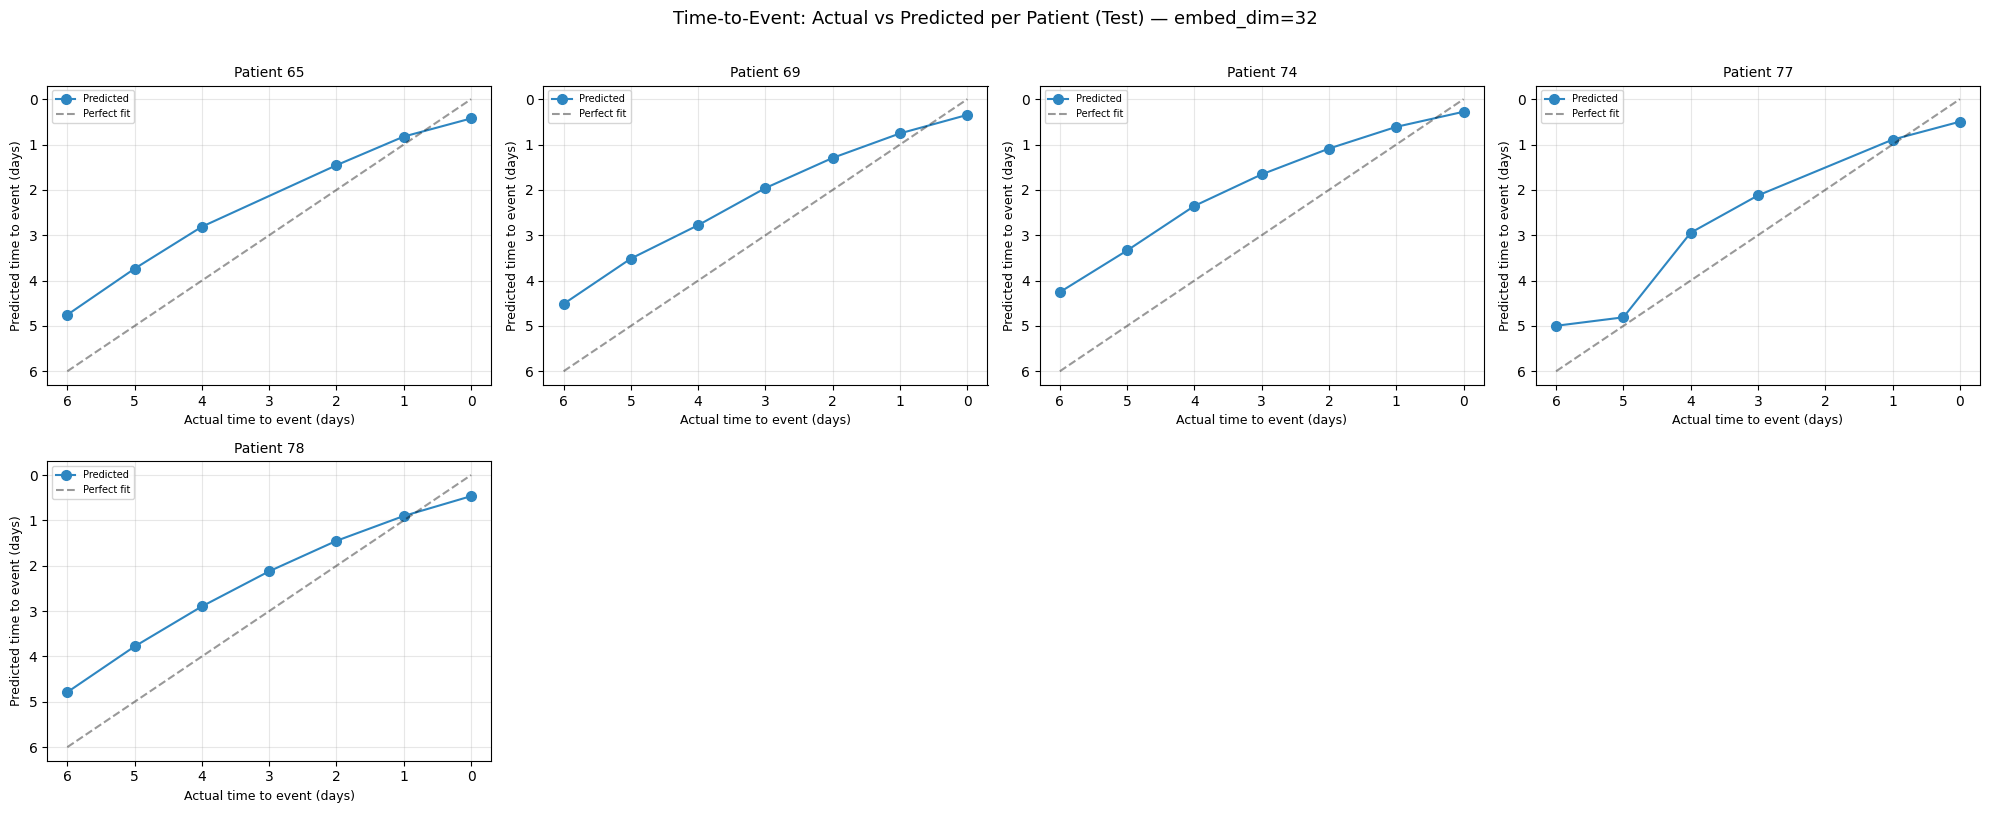

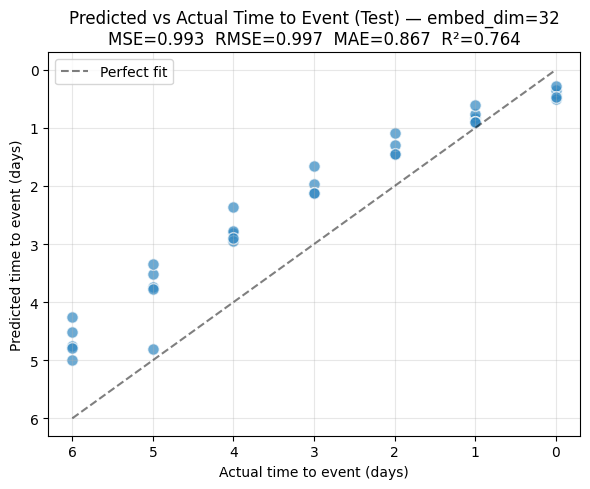

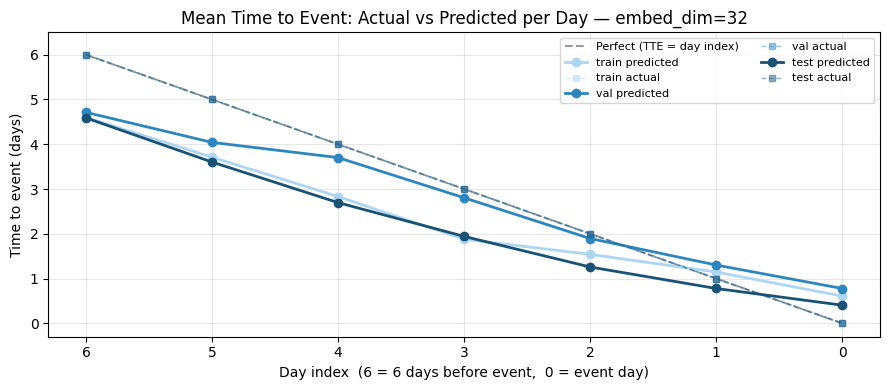

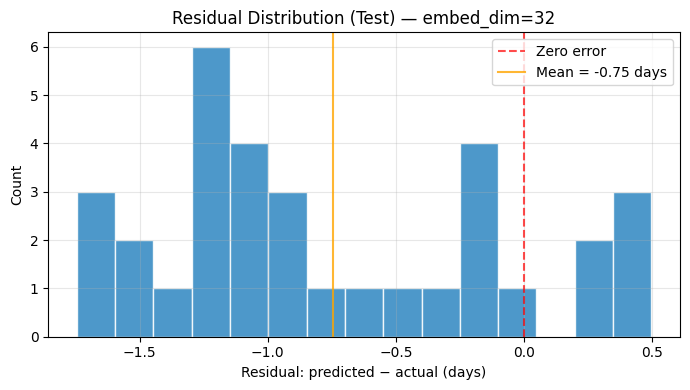


✅ All charts & tables saved → /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/Best_Model/regression_last7days/32dim


In [12]:
# ── Load best model ───────────────────────────────────────────────────────────
EMBED_DIM  = 32
NHEAD      = 4
HIDDEN_DIM = 128
dim_save        = os.path.join(SAVE_DIR, f'{EMBED_DIM}dim')
best_model_path = os.path.join(dim_save, 'best_model.pth')
model_eval, dev = load_best_model(best_model_path, EMBED_DIM, NHEAD, HIDDEN_DIM)

# ── Collect predictions ───────────────────────────────────────────────────────
split_dfs = {}
for sname, loader in [('train', train_loader),
                       ('val',   val_loader),
                       ('test',  test_loader)]:
    df_p = collect_predictions(loader, model_eval, log_target_scaler, dev)
    df_p['split'] = sname
    split_dfs[sname] = df_p

# ── Metrics table ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  METRICS — embed_dim={EMBED_DIM}')
print(f'{"="*60}')
print(f'  {"Split":>6}  {"MSE":>8}  {"RMSE":>8}  {"MAE":>8}  {"R²":>8}')
print('  ' + '-'*45)
metrics = {}
for sname, df_p in split_dfs.items():
    m = compute_metrics(df_p)
    metrics[sname] = m
    print(f'  {sname:>6}  {m["MSE"]:>8.4f}  {m["RMSE"]:>8.4f}  '
          f'{m["MAE"]:>8.4f}  {m["R2"]:>8.4f}')

# ── Per-patient tables (train / val / test) ───────────────────────────────────
# Full raw data printed and saved — use these to redraw any chart independently
for sname in ['train', 'val', 'test']:
    df_p = split_dfs[sname]
    tbl  = (df_p.groupby(['patient_id', 'day'], as_index=False)
                 .agg(actual_days=('time_to_event_actual', 'mean'),
                      pred_days  =('time_to_event_pred',   'mean')))
    tbl['error_days']  = (tbl['pred_days'] - tbl['actual_days']).round(3)
    tbl['actual_days'] = tbl['actual_days'].round(3)
    tbl['pred_days']   = tbl['pred_days'].round(3)
    tbl = tbl.sort_values(['patient_id', 'day']).reset_index(drop=True)

    print(f'\n{"="*65}')
    print(f'  PER-PATIENT TABLE — {sname.upper()}  (embed_dim={EMBED_DIM})')
    print(f'  Columns: patient_id | day (0=event day, 6=6 days before) | '
          f'actual_days | pred_days | error_days')
    print(f'{"="*65}')
    print(tbl.to_string(index=False))

    csv_path = os.path.join(dim_save, f'per_patient_{sname}.csv')
    tbl.to_csv(csv_path, index=False)
    print(f'  → Saved: per_patient_{sname}.csv  ({len(tbl)} rows, '
          f'{tbl["patient_id"].nunique()} patients)')

# ── Chart 1: Per-patient scatter — one subplot per patient (test) ─────────────
test_df   = split_dfs['test']
test_pids = sorted(test_df['patient_id'].unique())
n_pats    = len(test_pids)
n_cols    = min(4, n_pats)
n_rows    = (n_pats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5*n_cols, 4*n_rows), squeeze=False)
fig.suptitle(f'Time-to-Event: Actual vs Predicted per Patient (Test) — '
             f'embed_dim={EMBED_DIM}', fontsize=13, y=1.01)

for idx, pid in enumerate(test_pids):
    ax  = axes[idx//n_cols][idx%n_cols]
    sub = (test_df[test_df['patient_id'] == pid]
           .groupby('day', as_index=False)
           .agg(actual=('time_to_event_actual', 'mean'),
                pred  =('time_to_event_pred',   'mean'))
           .sort_values('day'))
    ax.plot(sub['actual'], sub['pred'], 'o-', color='#2E86C1',
            markersize=7, linewidth=1.5, label='Predicted')
    ax.plot([6, 0], [6, 0], 'k--', alpha=0.4, label='Perfect fit')
    ax.set_xlim(6.3, -0.3)
    ax.set_ylim(6.3, -0.3)
    ax.set_xlabel('Actual time to event (days)', fontsize=9)
    ax.set_ylabel('Predicted time to event (days)', fontsize=9)
    ax.set_title(f'Patient {pid}', fontsize=10)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

for idx in range(n_pats, n_rows * n_cols):
    axes[idx//n_cols][idx%n_cols].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'per_patient_tte_scatter.png'), dpi=150)
plt.show()

# ── Chart 2: All patients combined scatter (test) ────────────────────────────
test_daily = metrics['test']['daily']
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test_daily['actual'], test_daily['pred'],
           c='#2E86C1', alpha=0.7, edgecolors='white', s=70)
ax.plot([6, 0], [6, 0], 'k--', alpha=0.5, label='Perfect fit')
ax.set_xlim(6.3, -0.3)
ax.set_ylim(6.3, -0.3)
ax.set_xlabel('Actual time to event (days)')
ax.set_ylabel('Predicted time to event (days)')
ax.set_title(f'Predicted vs Actual Time to Event (Test) — embed_dim={EMBED_DIM}\n'
             f'MSE={metrics["test"]["MSE"]:.3f}  RMSE={metrics["test"]["RMSE"]:.3f}  '
             f'MAE={metrics["test"]["MAE"]:.3f}  R²={metrics["test"]["R2"]:.3f}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'scatter_test.png'), dpi=150)
plt.show()

# ── Chart 3: Mean predicted vs actual per day (all splits) ───────────────────
all_preds = pd.concat(split_dfs.values(), ignore_index=True)
daily_agg = (all_preds.groupby(['split', 'day'], as_index=False)
                       .agg(actual_mean=('time_to_event_actual', 'mean'),
                            pred_mean  =('time_to_event_pred',   'mean')))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([6, 5, 4, 3, 2, 1, 0], [6, 5, 4, 3, 2, 1, 0],
        'k--', alpha=0.4, label='Perfect (TTE = day index)')

colors = {'train': '#AED6F1', 'val': '#2E86C1', 'test': '#1A5276'}
for sname in ['train', 'val', 'test']:
    sub = daily_agg[daily_agg['split'] == sname].sort_values('day', ascending=False)
    ax.plot(sub['day'], sub['pred_mean'],   'o-',
            color=colors[sname], label=f'{sname} predicted',
            linewidth=2, markersize=6)
    ax.plot(sub['day'], sub['actual_mean'], 's--',
            color=colors[sname], alpha=0.45, label=f'{sname} actual',
            linewidth=1, markersize=5)

ax.set_xlim(6.3, -0.3)
ax.set_ylim(-0.3, 6.5)
ax.set_xlabel('Day index  (6 = 6 days before event,  0 = event day)')
ax.set_ylabel('Time to event (days)')
ax.set_title(f'Mean Time to Event: Actual vs Predicted per Day — embed_dim={EMBED_DIM}')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'per_day_tte_line.png'), dpi=150)
plt.show()

# ── Chart 4: Residual distribution (test) ────────────────────────────────────
resid = test_daily['pred'].values - test_daily['actual'].values
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(resid, bins=15, color='#2E86C1', edgecolor='white', alpha=0.85)
ax.axvline(0,            color='red',    linestyle='--', alpha=0.7, label='Zero error')
ax.axvline(resid.mean(), color='orange', linestyle='-',  alpha=0.8,
           label=f'Mean = {resid.mean():.2f} days')
ax.set_xlabel('Residual: predicted − actual (days)')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (Test) — embed_dim={EMBED_DIM}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(dim_save, 'residuals_test.png'), dpi=150)
plt.show()

print(f'\n✅ All charts & tables saved → {dim_save}')
del model_eval; gc.collect(); torch.cuda.empty_cache()